# Суть задания


1.   Рассмотреть разноуровневые API PyTorch.
2.   Реализовать простую сеть для классификации рукописных цифр из датасета MNIST.
3.   Реализовать простую сеть для классификации рукописных цифр из датасета FashionMNIST.
4. Решить головоломку с тремя фильтрами свёртки.

Примерное время выполнения - 6-8 часов.

Дедлайн: 1 октября 23:59

## Оценивание

Задание:

Часть работы | Стоимость в баллах
-------------|------------------
Реализована простая модель для MNIST | 5 (можно сдать без защиты)
Реализована простая модель для FashionMNIST | 3
Решена головоломка | 2
Итого | 10 баллов

Формула оценивания всей работы:

О = Задание * 0.9 + Тест на лекции 5 * 0.1

Штрафные коэффициенты оценивания при просрочке:

-|-
----|---
От 12 часов до 7 дней после дедлайна | 0.8
От 7 до 14 дней | 0.6
От 14 дней до конца модуля | 0.4

# Введение в PyTorch

В этом блокноте мы познакомимся с PyTorch, фреймворком глубокого обучения, который позволит нам быстро реализовывать и обучать модели.

В конце концов, **глубокое обучение - это просто математика**, которую мы могли бы реализовать с помощью какой-нибудь "голой" библиотеки вроде NumPy, но это заняло бы вечность и не очень хорошо масштабировалось. Поэтому мы используем такие библиотеки, как PyTorch, чтобы абстрагироваться от этих деталей и использовать готовые инструменты для проектирования сетей и их обучения без лишнего кода.

Для этого урока мы будем использовать Colab, так как GPU там бесплатные.

**Предполагается, что мы владеем базовым языком python и numpy** (см. [здесь](https://colab.research.google.com/github/cs231n/cs231n.github.io/blob/master/python-colab.ipynb#scrollTo=Numpy) базовое введение в numpy и его синтаксис и некоторые базовые сведения о Python).


### Что такое PyTorch?

PyTorch работает точно так же, как numpy, но при этом отслеживает на лету все операции, которые мы выполняем с объектами типа Tensor (которые ведут себя как [numpy.ndarray](https://numpy.org/doc/2.1/reference/generated/numpy.ndarray.html)). Он кэширует все необходимое для вычисления произвольных производных любой скалярной функции по любому элементу любого тензора, который использовался в вычислениях для этой скалярной функции (другими словами, вы сможете вычислить производную чего угодно по чему угодно). Это огромный шаг вперед по сравнению с временами динозавров, когда приходилось вычислять и подключать собственные производные к слоям нейронных сетей.

### Почему?

* Небольшой объем кода, но невероятная мощность
* Наш код теперь будет работать на GPU без необходимости напрямую обращаться к CUDA
* PyTorch используется повсеместно в научных исследованиях и в промышленности


## Как мне изучить PyTorch?

По PyTorch есть отличная серия учебников [здесь](https://pytorch.org/tutorials/).

Джастин Джонсон сделал отличный [учебник](https://github.com/jcjohnson/pytorch-examples) по PyTorch.

Вы также можете найти подробный [API doc](http://pytorch.org/docs/stable/index.html) здесь. В целом, документация по PyTorch невероятно обширна, и к ней следует обращаться всегда, когда у вас есть вопрос о том, как работает та или иная функция.

# Оглавление

Это задание состоит из 6 частей. В начале мы расскажем о PyTorch и его сходстве с numpy. Затем мы перейдем к рассказу о движке автоматического дифференцирования PyTorch. Мы быстро рассмотрим API и вызовы функций для загрузки наборов данных. Наконец, мы покажем 3 различных уровня абстракции, которые можно использовать для создания нейронных сетей.

1. Numpy / Torch
2. Автоматическая дифференциация
3. Наборы данных / загрузчики данных / аугментации
4. "Голый" PyTorch (низкоуровневый дизайн сети)
5. nn.Module PyTorch (проектирование сети среднего уровня)
6. nn.Sequential PyTorch (проектирование сети высокого уровня)

Вот таблица сравнения для каждого уровня абстракции:

| API | Гибкость | Удобство |
|---------------|-------------|-------------|
| "Голый" | High | Low |
| `nn.Module` | High | Medium | Medium |
| `nn.Sequential` | Низкий | Высокий |

# 1. Numpy / Torch

В этом разделе мы покажем вам некоторые сходства между numpy и pytorch.

PyTorch основан на объектах `Tensor()`. Они ведут себя точно так же, как массивы numpy, с точки зрения того, чем они являются и что вы можете с ними делать. Точно так же, как базовые массивы numpy с числами с плавающей точкой являются обобщениями матриц более высокой размерности, тензоры ничем не отличаются. Эти тензоры создаются как возвращаемое значение функции ``torch.tensor(data)``, где ``data`` - это (опционально вложенный) список целых чисел, плавающих чисел, булевых значений или даже самих ndarrays/других тензоров!

Как и в numpy, в pytorch есть множество математических операций, которые можно выполнять над тензорами... такие как сложение, поэлементное умножение, матричное умножение и т.д.

Нельзя не подчеркнуть, что, не обращая внимания на то, что происходит под капотом, тензоры ведут себя ТОЧНО ТАК ЖЕ, как и массивы, так что бояться нечего!

Это сходство еще раз демонстрируется в [этом](https://pytorch.org/tutorials/beginner/basics/tensorqs_tutorial.html) учебнике по pytorch.

## Cходство Numpy и PyTorch

In [1]:
import numpy as np
import torch

Cамый простой способ создания тензоров - просто передать вложенные списки в вызов функции torch.tensor(). Здесь мы создадим матрицу тождества 2x2 из вложенного списка.

In [2]:
data_a = [[1.,0.], [0., 1.]]
np_a = np.array(data_a)
torch_a = torch.tensor(data_a)


print('Numpy Array Contents and type:')
print('np array: \n', np_a, '\n', type(np_a), '\n', np_a.shape, '\n')
print('Torch Tensor Contents and type:')
print('torch tensor: \n', torch_a, '\n', type(torch_a), '\n', torch_a.shape)


Numpy Array Contents and type:
np array: 
 [[1. 0.]
 [0. 1.]] 
 <class 'numpy.ndarray'> 
 (2, 2) 

Torch Tensor Contents and type:
torch tensor: 
 tensor([[1., 0.],
        [0., 1.]]) 
 <class 'torch.Tensor'> 
 torch.Size([2, 2])


Мы видим, что даже индексирование в этих объектах работает одинаково!

In [3]:
print('Indexing at (i, j) = (1, 1)')
print(np_a[1, 1], type(np_a[1, 1]))
print(torch_a[1, 1], type(torch_a[1, 1]))

Indexing at (i, j) = (1, 1)
1.0 <class 'numpy.float64'>
tensor(1.) <class 'torch.Tensor'>


In [4]:
torch_a[1, 1].dtype

torch.float32

Мы также можем изменять форму наших массивов образом, схожим с NumPy.

Метод PyTorch [view](https://pytorch.org/docs/stable/generated/torch.Tensor.view.html) аналогичен методу numpy [reshape](https://numpy.org/doc/stable/reference/generated/numpy.reshape.html): он изменяет размеры тензора в соответствии с аргументами функции.

В качестве примера скажем, что мы хотим взять тензор формы `2 x 3 x 3` и переформировать его в тензор `2 x 9`. В выходном тензоре элементы будут расположены соответствующим образом:

```python
input[0, 0, 0] == output[0, 0]
input[0, 0, 1] == output[0, 1]
input[0, 0, 2] == output[0, 2]
# After this, we increment on the next dimension
# of the input tensor since the last two dimensions
# are only 3 long
input[0, 1, 0] == output[0, 3]
...
input[0, 2, 2] == output[0, 8]
input[1, 0, 0] == output[1, 0]
...
input[1, 2, 2] == output[1, 8]
```

В принципе, если перебрать все элементы тензоров (до и после переформирования), начиная с последнего размера, то порядок выводимых элементов будет одинаковым для обоих тензоров.

В PyTorch дополнительно есть еще один метод [reshape](https://pytorch.org/docs/stable/generated/torch.reshape.html): основное различие между ними заключается в том, что `.reshape` *может* копировать базовые данные тензора в новый тензор (более полное сравнение можно найти [здесь](https://stackoverflow.com/questions/49643225/whats-the-difference-between-reshape-and-view-in-pytorch)). Для большинства целей вы можете использовать `view` и `reshape` как взаимозаменяемые.

In [5]:
start = torch.zeros((2, 3, 3))
idx = 0
for i in range(start.shape[0]):
    for j in range(start.shape[1]):
        for k in range(start.shape[2]):
            start[i, j, k] = idx
            idx += 1
print("Before reshaping:")
print(start)
end = start.view(2, 9)
print("After reshaping")
print(end)
print()

print(start[0, 0, 0], end[0, 0])
print(start[0, 0, 1], end[0, 1])
print(start[0, 0, 2], end[0, 2])
print(start[0, 1, 0], end[0, 3])
print('...')
print(start[0, 2, 2], end[0, 8])
print(start[1, 0, 0], end[1, 0])
print('...')
print(start[1, 2, 2], end[1, 8])

test = start.view(3, 3, -1)
print(test)
print(test.size())

Before reshaping:
tensor([[[ 0.,  1.,  2.],
         [ 3.,  4.,  5.],
         [ 6.,  7.,  8.]],

        [[ 9., 10., 11.],
         [12., 13., 14.],
         [15., 16., 17.]]])
After reshaping
tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.],
        [ 9., 10., 11., 12., 13., 14., 15., 16., 17.]])

tensor(0.) tensor(0.)
tensor(1.) tensor(1.)
tensor(2.) tensor(2.)
tensor(3.) tensor(3.)
...
tensor(8.) tensor(8.)
tensor(9.) tensor(9.)
...
tensor(17.) tensor(17.)
tensor([[[ 0.,  1.],
         [ 2.,  3.],
         [ 4.,  5.]],

        [[ 6.,  7.],
         [ 8.,  9.],
         [10., 11.]],

        [[12., 13.],
         [14., 15.],
         [16., 17.]]])
torch.Size([3, 3, 2])


Мы видим, что массивы numpy и тензоры pytorch имеют одинаковые типы операций, связанных с ними. Все они поддерживают + (сложение), - (вычитание), * (поэлементное умножение), @ (матричное умножение, где операндами являются матрицы) и даже операции истинности == и >= (практически, любой синтаксис, который работает с массивами numpy, скорее всего, будет работать и с тензорами pytorch).

In [6]:
data_b = [[1., 1.], [1., 1.]]
np_b = np.array(data_b)
torch_b = torch.tensor(data_b)

print('Matrix a\n', np_a, '\nMatrix b\n', np_b, '\n')

print('----------------------')
print('Addition (a + b)')
print('numpy array: \n', np_a + np_b)
print('torch tensor: \n', torch_a + torch_b)
print()

print('----------------------')
print('Subtraction (a - b)')
print('numpy array: \n', np_a - np_b)
print('torch tensor: \n', torch_a - torch_b)
print()

print('----------------------')
print('Elementwise Multiplication (a * b)')
print('numpy array: \n', np_a * np_b)
print('torch tensor: \n', torch_a * torch_b)
print()

print('----------------------')
print('Matrix Multiplication (a @ b)')
print('numpy array: \n', np_a @ np_b)
print('torch tensor: \n', torch_a @ torch_b)
print()


Matrix a
 [[1. 0.]
 [0. 1.]] 
Matrix b
 [[1. 1.]
 [1. 1.]] 

----------------------
Addition (a + b)
numpy array: 
 [[2. 1.]
 [1. 2.]]
torch tensor: 
 tensor([[2., 1.],
        [1., 2.]])

----------------------
Subtraction (a - b)
numpy array: 
 [[ 0. -1.]
 [-1.  0.]]
torch tensor: 
 tensor([[ 0., -1.],
        [-1.,  0.]])

----------------------
Elementwise Multiplication (a * b)
numpy array: 
 [[1. 0.]
 [0. 1.]]
torch tensor: 
 tensor([[1., 0.],
        [0., 1.]])

----------------------
Matrix Multiplication (a @ b)
numpy array: 
 [[1. 1.]
 [1. 1.]]
torch tensor: 
 tensor([[1., 1.],
        [1., 1.]])



PyTorch даже поддерживает некоторые из операций линейной алгебры, которые поддерживает numpy! Не все из них имеют одинаковые названия функций, но те, что приведены ниже, имеют. Здесь мы показываем только функции для вычисления норм и инверсий, но, как и в numpy, в torch есть функции для всего: от QR-разложений до SVD и решения систем линейных уравнений.

In [7]:
print('Norm -------------------------')
data_v = [0.6, 0.8]
np_v = np.array(data_v)
torch_v = torch.tensor(data_v)
print('numpy array: \n', np.linalg.norm(np_v))
print('torch tensor: \n', torch.linalg.norm(torch_v))
print()

print('Inverse ---------------------')
data_M = [[0.4, 0.3], [-0.3, 0.4]]
np_M = np.array(data_M)
torch_M = torch.tensor(data_M)
print('numpay array: \n', np.linalg.inv(np_M))
print('torch tensor: \n', torch.linalg.inv(torch_M))

Norm -------------------------
numpy array: 
 1.0
torch tensor: 
 tensor(1.)

Inverse ---------------------
numpay array: 
 [[ 1.6 -1.2]
 [ 1.2  1.6]]
torch tensor: 
 tensor([[ 1.6000, -1.2000],
        [ 1.2000,  1.6000]])


Наконец, мы также можем конвертировать туда и обратно тензоры и массивы. Мы можем вызвать ``torch.tensor()`` на ndarray, чтобы получить его как тензор, или вызвать ``.numpy()`` на tensor, чтобы получить его numpy-версию.

In [8]:
print(torch.tensor(np_a))
print(torch_a.numpy())

tensor([[1., 0.],
        [0., 1.]], dtype=torch.float64)
[[1. 0.]
 [0. 1.]]


## Устройства

Одно из основных различий между pytorch и numpy: использование GPU. В приведенном ниже блоке кода мы определим «устройство» как объект, возвращаемый вызовом ``torch.device('cuda')`` или ``torch.device('cpu')``. Затем эти объекты можно передавать в новые тензоры, которые мы создаем, указывая, на каком устройстве они должны храниться. Вы также можете перемещать существующие тензоры по устройствам с помощью функции ``.to()``: вызов ``x.to(device)`` на тензоре ``x`` переместит его на указанное устройство.

У вас есть возможность **использовать GPU, установив флаг ``USE_GPU`` в True ниже**. Рекомендуется, но не обязательно использовать GPU для этого задания. Обратите внимание, что если на вашем компьютере не включена CUDA, то `torch.cuda.is_available()` вернет False и ноутбук вернется в режим CPU. Глобальные переменные `dtype` и `device` будут управлять типами данных во время выполнения этого задания.

Если вы используете Colab, вам нужно вручную переключиться на устройство GPU. Это можно сделать, нажав `Runtime -> Change runtime type` и выбрав `GPU` в разделе `Hardware Accelerator`. Обратите внимание, что вам придется заново запускать ячейки сверху, так как при переключении среды выполнения ядро перезапускается.

In [9]:
USE_GPU = True

dtype = torch.float32 # we will use the float32 data type throughout this tutorial

if USE_GPU and torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print('using device:', device)

using device: cpu


In [10]:
# укороченная версия
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('using device:', device)

using device: cpu


Здесь мы видим тензор, где используемое устройство задано при создании, и другой пример, в котором мы отправляем существующий тензор на устройство. Если у вас действительно включен GPU, вы должны увидеть ``cuda:0`` в качестве типа устройства для этих тензоров. **Последний пример не должен работать, потому что отправка тензора на устройство с помощью вызова ``.to()`` возвращает НОВЫЙ объект, который хранится на новом устройстве... операция ``.to()`` не является операцией «in place»!**.

В дальнейшем вы будете использовать функцию ``.to()`` для сетей и тензоров, чтобы отправлять целые нейронные сети и партии данных на GPU во время обучения!

In [11]:
a = torch.randn((2, 2), device = device)
print(a)

a = torch.randn((2, 2))
a = a.to(device)
print(a, a.device)

a = torch.randn((2, 2))
a.to(device)
print(a, a.device)

tensor([[ 0.1307,  0.5245],
        [ 1.6048, -1.6336]])
tensor([[-0.1237,  0.6928],
        [-0.4812, -0.1517]]) cpu
tensor([[1.4020, 2.2624],
        [0.3624, 0.7807]]) cpu


Следующая ячейка выдаст ошибку, если значение device было определено как 'cuda' (т.е. GPU). Это происходит потому, что тензоры на разных устройствах не могут работать вместе. В этом есть смысл, потому что как вы собираетесь выполнять арифметические операции над тензорами, которые находятся на разных устройствах?

Пусть это будет предостережением на будущее, когда вы будете обучать свои сети: если ваша сеть работает на GPU, убедитесь, что вы отправляете свои батчи данных также на GPU.

In [12]:
torch.randn((2, 2), device = device) + torch.randn((2, 2))

tensor([[-0.0990,  0.1030],
        [-1.7221, -0.1710]])

Feel free to comment out the line above once you have seen what the errors looks like!

In [13]:
a = torch.tensor([5])
a = a.float()
a.dtype

torch.float32

### Насчёт приведения типов
О приведении ``.float()`` (которое, как следует из названия, преобразует тензор к типу данных float), также полезно знать.

# 2.  PyTorch Autograd

Мы показали, что на первый взгляд тензоры torch имеют ту же функциональность, что и массивы numpy, но под капотом происходит гораздо больше! **Мы можем указать, что хотим взять производные выхода тензора по элементам другого тензора при оценке в определенных точках.** Хотя torch не будет выдавать символьные производные типа ``f(x, w) = xw^2 ==> df/dw = 2wx``, он будет оценивать ``df/dw`` при определенном значении ``x`` для определенного значения ``w``, а это все, что нам действительно нужно для глубокого обучения.

**Обратите внимание, что единственная синтаксическая вещь, которую вы должны вынести для себя из этой части, это то, что ``x.backward()`` будет вычислять частные производные каждого тензора относительно ``x``.** Вам никогда не придется заходить и смотреть, что такое атрибут ``.grad`` у тензора. Мы будем использовать нечто под названием Optimizers позже, что будет обрабатывать обновления градиента для нас автоматически.

Учебник по автоматическому дифференцированию в pytorch смотрите [здесь](https://pytorch.org/tutorials/beginner/basics/autogradqs_tutorial.html).

In [14]:
import torch

Начнем с базовой функции, ``f(x, w) = x*w^2``, как в примере выше. Сначала мы зададим значение ``w``, при котором мы хотим оценить производную ``f``.

Поскольку нам нужно взять производную этой функции по ее входам, нам нужно как-то указать PyTorch, чтобы он разрешил дифференцирование по этим входам. Для каждого тензора, относительно которого мы хотим иметь возможность дифференцировать функцию, мы установим для его поля ``.requires_grad`` значение True. Это гарантирует, что после построения вычислительного графа и запуска обратного распространения у этих тензоров появится дополнительный атрибут, хранящий их градиенты.

Предупреждение: следующая ячейка приведет к ошибке!


In [15]:
w = torch.tensor(5)
w.requires_grad = True

RuntimeError: only Tensors of floating point and complex dtype can require gradients

О нет! Этого следовало ожидать. Torch говорит нам, что для того, чтобы иметь возможность дифференцировать относительно чего-то, это что-то должно быть числом с плавающей точкой. Это имеет смысл, потому что производная работает только в непрерывном пространстве, а целые числа дискретны (технически, числа с плавающей точкой тоже дискретны, но они являются наилучшим представлением непрерывных вещественных чисел, которое могут понять компьютеры). Не стесняйтесь закомментировать ячейку выше после того, как увидите, как выглядит ошибка.

Эта проблема может возникнуть и доставить вам массу неприятностей, если вы не будете осторожны, особенно если учесть, что мы часто загружаем изображения, в которых значения пикселей являются целыми числами в диапазоне [0, 255].

На всякий случай, если вы не уверены в типе объекта, лучше просто приводить его к нужному типу.


In [16]:
w = w.float()
w.requires_grad = True

x = torch.tensor(4)

Теперь мы оценим `y = f(x, w)` с помощью наших тензоров. Волшебная вещь в pytorch заключается в том, что нам нужно только указать, как оценить функцию, и pytorch позаботится обо всем остальном за нас! Итак, оценим же наше выражение:


In [17]:
y = x * (w ** 2)
print(y, type(y))

tensor(100., grad_fn=<MulBackward0>) <class 'torch.Tensor'>


Видно, что ``f(x, w)`` была вычислена правильно, так как ``x = 4`` и ``w = 5``. Мы также можем видеть поле `grad_fn` в тензоре. Не так важно, что это такое, но должно быть понятно, что pytorch уже опережает события и хранит всю информацию, необходимую для последующего вычисления производных, что и происходит при вызове функции `.backward()`.

Функция `a.backward()` указывает pytorch на то, что нужно заранее взять производные `a` относительно всех тензоров, которые использовались для создания `a`. Полученные результаты будут храниться в полях `.grad` этих тензоров.

В более общем случае, в контексте обратного распространения для нейронных сетей, **метод `a.backward()` имеет смысл только в том случае, если тензор `a` содержит только один скаляр, а не вектор или матрицу. В противном случае вы вычисляете производную вектора или матрицы по скалярному весу, что даст другой вектор / матрицу вместо скаляра.** Поскольку компоненты наших весов являются скалярами, мы хотим, чтобы производные нашей функции потерь по этим компонентам также были скалярами (чтобы мы могли выполнить шаг градиентного спуска). Именно поэтому при выполнении пакетного градиентного спуска вы усредняете потери по всем обучающим примерам, получая единую скалярную потерю (loss) для этого пакета, по которому мы можем осуществлять обратное распространение.


In [18]:
y.backward()
print(w.grad)

tensor(40.)


Ура! Этого и следовало ожидать, поскольку ``df/dw = 2*w*x = 2*5*4`` при ``w = 5`` и ``x = 4``. Давайте посмотрим, что произойдет, если мы снова запустим ту же ячейку, но с другим значением `w`:


In [19]:
w.data = torch.tensor(3.)
y = x * (w ** 2)
print(y)
y.backward()
print(w.grad)

tensor(36., grad_fn=<MulBackward0>)
tensor(64.)


Что случилось? Мы видим, что `y = f(4, 3) = 36.` оценивается правильно. Это означает, что `df/dw` должно было быть `2(4)(3) = 24.`, но мы видим `64.` в `w.grad` вместо `24.`?

**Оказывается, когда pytorch вычисляет производную `y` относительно `w`, он не перезаписывает атрибут `.grad` в `w`, а фактически добавляет его in place.** Наш атрибут `.grad` изначально был `40.`, а когда мы выполнили еще одну итерацию вычисления градиентов, новая производная `24.`, но вместо перезаписи в новый градиент pytorch добавил к предыдущему значению поля `w.grad`.
Это полезно при использовании «градиентного накопления» (сейчас это нам не нужно, но как-нибудь можете погуглить).

**Вот почему после каждой пачки (батча) данных, на которых вы выполняете обратное распространение ошибки, вам нужно очищать градиенты модели.** Мы расскажем вам, как именно это делать, но пусть это будет предостережением, что очищать градиенты между шагами градиента нужно в любом случае.




В более общем случае мы можем создать любую функцию `f`, принимающую произвольные параметры, и при этом осуществлять обратное распространение от выхода функции ко входам. Для примера создадим функцию `f`, которая является ранее заданной квадратичной фукнцией, но знайте, что вы можете создать любую функцию, если операции внутри нее дифференцируемы.


In [20]:
# нам следует обнулить атрибут w.grad, чтобы в этот раз мы увидели правильный градиент
w.grad.zero_()

def f(w, x):
    return x * (w ** 2)


y = f(w, x)
y.backward()
print(w.grad)

tensor(24.)


Теперь вы можете использовать pytorch для вычисления произвольных производных, оцененных в произвольных значениях.

У PyTorch есть [хороший учебник](https://pytorch.org/tutorials/beginner/basics/autogradqs_tutorial.html), который показывает более сложный пример с красивыми диаграммами и более подробно рассказывает о том, как он отслеживает различные тензорные вычисления, и мы рекомендуем вам ознакомиться с ним.


# 3. Наборы данных и загрузка данных

Одна из важнейших частей обучения нейронных сетей - работа с данными и знание того, как их аугментировать/преобразовать.

Мы будем использовать `torch.utils.data` в качестве основы нашего пайплайна загрузки данных в модель, используя его для создания наборов данных и загрузчиков данных. Кроме того, библиотека `torchvision` (подмножество pytorch, содержащее методы, полезные для задач компьютерного зрения) также будет использоваться для выполнения аугментаций данных.

Официальное введение torch в создание наборов данных и загрузчиков данных находится [здесь](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html), а список преобразований (дополнений) в torchvision доступен [здесь](https://pytorch.org/vision/stable/transforms.html).



In [21]:
# Some misc imports used for demonstrations
import matplotlib.pyplot as plt

# What we actually need for this to work
import torch
from torch.utils.data import Dataset, DataLoader, sampler
import torchvision.datasets as datasets
import torchvision.transforms as T

## Datasets

Набор данных в PyTorch - это любой класс, наследующий от родительского класса `torch.utils.data.Dataset`, со следующими 3 методами:
1. ` __init___(self, ...):`.
Это функция инициализации, в которую вы можете передать любые аргументы, необходимые для вашего пользовательского набора данных. Сохраните здесь всю информацию из аргументов в переменных экземпляра, чтобы потом было легко получить ее в методах, приведенных ниже.
2. `__len__(self):`
Здесь вам нужно просто вернуть длину вашего набора данных (т.е. количество образцов в наборе данных).
3. ` __getitem__(self, idx):`
Это основная часть класса dataset. Это функция, которая должна принимать в качестве аргументов `self` и `idx`, и больше ничего. Здесь `idx` будет целым числом от 0 (включительно) до длины вашего набора данных (исключительно). Вы должны вернуть тензор(ы), соответствующий `idx`-му обучающему примеру (преобразованный/дополненный по вашему желанию), и любые другие данные, которые вы можете пожелать (например, метку или любые соответствующие метаданные). В большинстве случаев, для данных об изображениях, это включает в себя: открытие файла изображения -> преобразование его в тензор -> применение любых аугментаций -> вывод конечного изображения и соответствующей метки.

Ниже показано, как будет выглядеть ваш набор данных, описанный в шаблонном коде.


In [22]:
class custom_dataset(Dataset):
    def __init__(self, **kwargs):
        pass # Вставьте сюда свой код, чтобы инициализировать набор данных и загрузить то, что вам нужно

    def __getitem__(self, idx):
        pass # Выясните, как загрузить и вернуть idx-ый элемент в наборе данных
        return x, label, other_misc_information_you_may_want

    def __len__(self):
        pass # Возвращает длину набора данных

Давайте создадим игрушечный набор данных, где пары `(x, y)` - это `(x, sin(x))` соответственно, то есть наш набор данных - это просто входы и выходы функции синуса.


In [23]:
class sin_dataset(Dataset):
    def __init__(self, num_examples, x_range):
        """
        Документация здесь:
        num_examples - количество примеров, которые мы хотим получить из этого набора данных.
        x_range - кортеж из (lowest_possible_x, highest_possible_x)
        """
        self.num_examples = num_examples
        #  torch.rand(shape) выводит тензор с формой `shape`, значения элементов которого равномерно распределены в диапазоне [0, 1)
        self.x_vals = (torch.rand(num_examples) * (x_range[1] - x_range[0])) + x_range[0]

    def __getitem__(self, idx):
        return self.x_vals[idx], torch.sin(self.x_vals[idx])

    def __len__(self):
        return self.num_examples

Мы можем обращаться по индексу к элементам этого набора данных, как только создадим объект sin_dataset, и даже выполнять итерации по нему!

Это даёт очень удобный способ обращения с данными, добавляя хорошую структурированную абстракцию для процесса получения и загрузки данных.


0-th entry (tensor(1.6187), tensor(0.9989))
1-th entry (tensor(-1.3866), tensor(-0.9831))


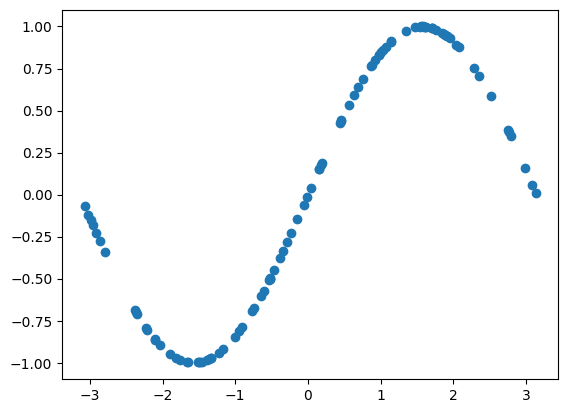

In [24]:
torch.manual_seed(1)  # Закрепление значения seed генератора случайных чисел для воспроизводимости, можно удалить, если это не нужно
ds = sin_dataset(100, (-torch.pi, torch.pi))

print('0-th entry', ds[0])
print('1-th entry', ds[1])

xs = []
ys = []
for x, y in ds:
  xs.append(x)
  ys.append(y)

plt.scatter(xs, ys)
plt.show()

## Dataloaders

Теперь давайте узнаем о загрузчиках данных. Они оборачивают объекты наборов данных, могут разбивать их на пакеты (батчи), перемешивать их, если мы этого хотим (а обычно мы этого хотим). Они используют многопроцессную обработку под капотом для быстрого получения данных, обеспечивая еще один уровень абстракции в процессе загрузки данных, позволяя нам теперь просто получать пакеты данных.

Базовый класс PyTorch `DataLoader()` будет автоматически разбивать на пакеты данные для нас. Если наш набор данных выдает 4 тензора в функции `getitem(self, idx)`, то загрузчик данных выдает (в том же порядке) 4 пакета тензоров, где дополнительное измерение (размерность пакета) добавляется в качестве первого измерения.

В случае визуальных данных, если ваши изображения имеют размер `C x H x W` (каналы в изображении, ширина, высота), dataloader вернёт пакетный тензор `batch[]` размера `N x C x H x W`, где `N` - количество объектов в пакете `batch[]`, а `batch[i]` - `i`-й обучающий пример (поскольку мы индексировали по первому измерению, которое является размерностью партии).

Мы не будем рассматривать способы создания собственного загрузчика данных, поскольку, пока вы возвращаете тензоры, независимо от их количества, pytorch почти всегда будет выполнять пакетную обработку правильно. Для более сложных данных вам, возможно, придется определить собственные функции пакетной обработки (но это, как правило, чаще делается в NLP, чем в CV).


In [25]:
# мы хотим, чтобы кажый пакет содержал 10 образцов
# поскольку мы установили shuffle=False, первый пакет будет содержать первые 10 образцов (idx в диапазоне(0, 10)) набора данных,
# следующая партия будет содержать следующие 10 образцов (idx в диапазоне(10, 20)) и так далее
loader = DataLoader(ds, batch_size=10, shuffle=False)

batch_x, batch_y = next(iter(loader))
print('Batched x', batch_x)
print('Batched y', batch_y)


for i, (x, y) in enumerate(ds):
    if i >= 10: # Нам нужны только первые 10
        break
    print('Example ' + str(i) + '     ', 'x: ', x, '    y: ', y)

Batched x tensor([ 1.6187, -1.3866, -0.6090,  1.4746, -2.9576,  1.8841, -0.6463,  1.5983,
         0.4367, -0.3847])
Batched y tensor([ 0.9989, -0.9831, -0.5721,  0.9954, -0.1829,  0.9513, -0.6022,  0.9996,
         0.4230, -0.3753])
Example 0      x:  tensor(1.6187)     y:  tensor(0.9989)
Example 1      x:  tensor(-1.3866)     y:  tensor(-0.9831)
Example 2      x:  tensor(-0.6090)     y:  tensor(-0.5721)
Example 3      x:  tensor(1.4746)     y:  tensor(0.9954)
Example 4      x:  tensor(-2.9576)     y:  tensor(-0.1829)
Example 5      x:  tensor(1.8841)     y:  tensor(0.9513)
Example 6      x:  tensor(-0.6463)     y:  tensor(-0.6022)
Example 7      x:  tensor(1.5983)     y:  tensor(0.9996)
Example 8      x:  tensor(0.4367)     y:  tensor(0.4230)
Example 9      x:  tensor(-0.3847)     y:  tensor(-0.3753)


Здесь мы создали итерабельный объект (см. [здесь](https://www.w3schools.com/python/python_iterators.asp) учебник по итераторам в python) из нашего загрузчика данных, вызвав `iter(loader)`. Мы извлекли его первый элемент, вызвав `next()`, который вернул 2 тензора: пакет из первых 10 значений `x` и пакет из первых 10 значений `y`. Порядок одинаковый, а сами значения неизменны, в чем мы можем убедиться, распечатав вручную первые 10 элементов из набора данных.

В циклах обучения вы будете выполнять итерации по загрузчику данных, делая примерно следующее:

```python
for batch in train_loader:
    x, label = batch
    # Шаг градиентного спуска
```


## Преобразования изображений

И последнее, что вам следует знать (прежде чем мы загрузим реальный набор данных и двинемся дальше), - как преобразовывать/аугментировать изображения. Для этого мы обычно используем преобразования, определенные в `torchvision.transforms` (хотя, в зависимости от проблемы, над которой вы работаете, вам может потребоваться определить собственные преобразования). Это будут объекты, вызываемые на некоторых данных и возвращающие преобразованную версию этих данных.

Ниже приведен пример базового преобразования: преобразование `ToTensor()`. Это объект, который принимает массивы numpy или изображения PIL (другой формат представления файлов изображений в python, реализуемый библиотекой Pillow) и возвращает их тензорную версию.
Следует быть осторожным: PIL или numpy изображения представлены в форме `H x W x C`, и `ToTensor()` автоматически транспонирует их в форму `C x H x W`, которую использует pytorch. Кроме того, изображения в PIL или numpy обычно представляют собой целые числа в диапазоне `[0, 255]` (каждый пиксель - 1 бит), а `ToTensor()` уменьшает их до плавающих чисел в диапазоне `[0., 1.]`.


In [26]:
transform = T.ToTensor()

test = np.arange(256).reshape(16, 16).astype(np.uint8)
print('This is the original np array')
print(type(test))
print(test, '\n\n')

transformed = transform(test)
print('This is the transformed array')
print(type(transformed))
print(transformed)

This is the original np array
<class 'numpy.ndarray'>
[[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15]
 [ 16  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31]
 [ 32  33  34  35  36  37  38  39  40  41  42  43  44  45  46  47]
 [ 48  49  50  51  52  53  54  55  56  57  58  59  60  61  62  63]
 [ 64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79]
 [ 80  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95]
 [ 96  97  98  99 100 101 102 103 104 105 106 107 108 109 110 111]
 [112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127]
 [128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143]
 [144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159]
 [160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175]
 [176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191]
 [192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207]
 [208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223]
 [224 22

Здесь вы можете увидеть, что мы сделали и как это работает. Мы берем экземпляр объект transform, а затем, по сути, обращаемся к нему как к функции, вызывая ее для данных, которые мы хотим преобразовать. Немного необычно, но довольно просто. Мы можем делать это с целым рядом преобразований в библиотеке torchvision, описанных [здесь](https://pytorch.org/vision/stable/transforms.html) (нужно быть внимательными, потому что некоторые преобразования принимают в качестве входных данных только массивы numpy или изображения PIL, а другие - только тензорные объекты). В примере, показанном ниже, мы скомпонуем их с помощью `transforms.Compose`. Для задач компьютерного зрения очень полезно определять аугментации изображений, используя класс `torchvision.transforms`.


--2026-09-28 19:13:10--  https://upload.wikimedia.org/wikipedia/commons/c/c5/Peacock_Plumage.jpg
Resolving upload.wikimedia.org (upload.wikimedia.org)... 

185.15.59.240
Connecting to upload.wikimedia.org (upload.wikimedia.org)|185.15.59.240|:443... 

connected.


HTTP request sent, awaiting response... 

200 OK
Length: 1972892 (1,9M) [image/jpeg]
Saving to: ‘image.jpg’

image.jpg             0%[                    ]       0  --.-KB/s               

image.jpg            56%[==========>         ]   1,07M  5,31MB/s               

image.jpg           100%[===================>]   1,88M  7,07MB/s    in 0,3s    

2026-09-28 19:13:10 (7,07 MB/s) - ‘image.jpg’ saved [1972892/1972892]






Наше исходное изображение


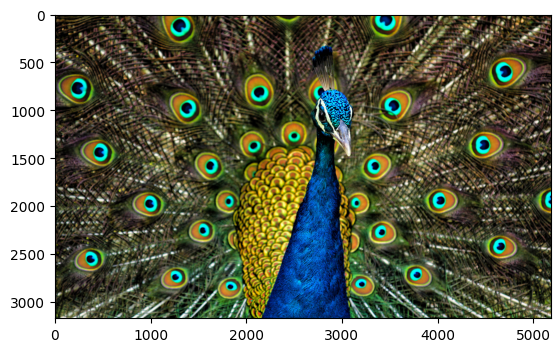

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torchvision/transforms/functional.py:152: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:212.)
  img = torch.from_numpy(pic.transpose((2, 0, 1))).contiguous()
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To supp

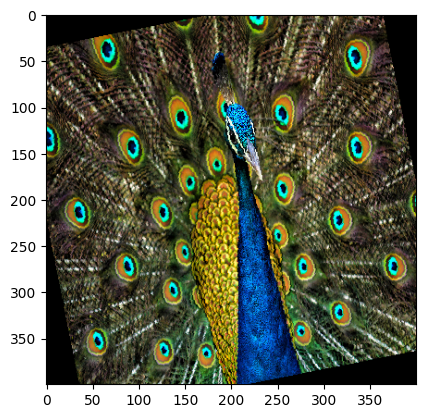

torch.Size([3, 400, 400])


In [27]:
# Так мы получим тестовое изображение для использования
!wget -O image.jpg https://upload.wikimedia.org/wikipedia/commons/c/c5/Peacock_Plumage.jpg


img_as_np = plt.imread('image.jpg')

print('\n\n\nНаше исходное изображение')
plt.imshow(img_as_np)
plt.show()

transform = T.Compose([
                T.ToTensor(),
                T.Resize((400, 400)),
                T.RandomRotation(degrees=20)
            ])

output_tensor = transform(img_as_np)

plt.imshow(output_tensor.permute(1, 2, 0).numpy())
plt.show()
print(output_tensor.shape)

Здесь вы видите исходное изображение и изображение после того, как оно прошло через наше преобразование (которое затем было обратно преобразовано в массив numpy). Сначала мы превратили его в тензор (с помощью `ToTensor()`), затем изменили размер до `400 x 400` (с помощью `Resize((400, 400))`) и, наконец, повернули его на некоторый случайный угол между (-20, 20) (с помощью `RandomRotation(degrees=20)`).

\- Примечание -

Вы можете заметить, что нам понадобилось выполнить `output_tensor.permute(1, 2, 0)`, прежде чем мы преобразовали результат в массив numpy. Как упоминалось ранее, в PyTorch принято указывать количество каналов изображения перед пространственными размерами (формат `C x H x W`), в то время как в matplotlib, PIL и некоторых других библиотеках для зрения принято указывать его в конце (формат `H x W x C`).
Поэтому перед построением графика в matplotlib нам нужно было соответствующим образом «пермутировать» или «транспонировать» тензор, чтобы изменить порядок его размерностей.


И последнее замечание: Мы не будем рассматривать его в этом конкретном блокноте, но для вашего ознакомления существует впечатляющая библиотека преобразований компьютерного зрения Albumentations [здесь](https://albumentations.ai/docs/getting_started/transforms_and_targets/), которая является одной из самых лучших библиотек для преобразования изображений, особенно когда вам нужно произвольно дополнить изображение и соответствующие ему метки (например, ключевые точки или маски сегментации). Для базовых задач классификации, где аугментация данных не должна изменить прогноз, достаточно встроенных преобразований torchvision.


## Prefab Dataset

У нас также есть множество готовых, общедоступных наборов данных, которые мы можем получить из torchvision (полный список см. [здесь](https://pytorch.org/vision/stable/datasets.html)). Некоторые из них позволяют нам загружать данные напрямую, но в других случаях, как в случае с ImageNet, вам придется предоставлять данные самостоятельно. Ниже мы воспользуемся этим, чтобы загрузить набор данных `CIFAR-10`.

Примечание: здесь мы используем наборы данных компьютерного зрения, но в дополнение к torchvision в PyTorch есть такие библиотеки, как `torchaudio` и `torchtext`, поэтому в зависимости от вашей специализации вы можете захотеть самостоятельно изучить эти конкретные библиотеки.


In [28]:
NUM_TRAIN = 49000

# Здесь мы настраиваем преобразование для предварительной обработки данных путем
# нормализации RGB значений; среднее значение и стандартное отклонение мы задали сами.
# Если мы хотим добавить аугментации к данным, мы можем добавить преобразования из
# torchvision к объекту Compose ниже. Однако нам придется создать два набора
# преобразований: один для обучающего даталоадера, а другой для тестового / проверочного даталоадера.

transform = T.Compose([
                T.ToTensor(),
                T.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
            ])

# Мы создаем объект Dataset для каждого сплита (train / val / test); Datasets загружают
# тренировочные примеры по одному, поэтому мы оборачиваем каждый Dataset в DataLoader, который
# выполняет итерации по набору данных и формирует минибатчи. Мы разделили набор CIFAR-10
# на наборы train и val, передавая объект Sampler в DataLoader, который определяет,
# как он должен делать выборку из базового набора данных.
# Вы также можете просто взять подмножества набора данных и передать их в отдельные
# загрузчики данных, чтобы создать свои собственные тренировочные и тестовые наборы.

cifar10_train = datasets.CIFAR10('./datasets', train=True, download=True,
                                 transform=transform)
loader_train = DataLoader(cifar10_train, batch_size=64,
                          sampler=sampler.SubsetRandomSampler(range(NUM_TRAIN)))

cifar10_val = datasets.CIFAR10('./datasets', train=True, download=True,
                               transform=transform)
loader_val = DataLoader(cifar10_val, batch_size=64,
                        sampler=sampler.SubsetRandomSampler(range(NUM_TRAIN, 50000)))

cifar10_test = datasets.CIFAR10('./datasets', train=False, download=True,
                                transform=transform)
loader_test = DataLoader(cifar10_test, batch_size=64)

Using downloaded and verified file: ./datasets/cifar-10-python.tar.gz
Extracting ./datasets/cifar-10-python.tar.gz to ./datasets


Files already downloaded and verified


Files already downloaded and verified


Давайте проверим форму тензоров, возвращаемых в каждом пакете:


In [29]:
x, y = next(iter(loader_train))
print(x.shape)
print(y.shape)
# x shape - 64, 3, 32, 32
# y shape - 64, 1

torch.Size([64, 3, 32, 32])
torch.Size([64])


Число 64 в начале имеет смысл, поскольку выше мы указали его в качестве размера пакета. Оставшиеся 3 числа указывают на то, что каждое изображение в наборе данных CIFAR10 имеет размер `3 x 32 x 32`, т. е. RGB-изображения разрешения `32 x 32` пикселя.


In [30]:
print(x)
print(y)

tensor([[[[-1.8863e+00, -1.8475e+00, -1.7506e+00,  ..., -5.4873e-01,
           -1.0915e+00, -1.0334e+00],
          [-1.6343e+00, -1.2466e+00, -8.2012e-01,  ..., -7.8135e-01,
           -8.9766e-01, -8.3950e-01],
          [-1.0915e+00, -3.1611e-01,  2.2667e-01,  ..., -8.2012e-01,
           -7.2319e-01, -6.2627e-01],
          ...,
          [-5.0996e-01, -6.6504e-01, -6.6504e-01,  ..., -7.2319e-01,
           -6.4565e-01, -6.6504e-01],
          [-5.8750e-01, -7.4258e-01, -7.0381e-01,  ..., -6.6504e-01,
           -4.3242e-01, -5.0996e-01],
          [-7.6196e-01, -8.5889e-01, -7.8135e-01,  ..., -4.5180e-01,
           -3.3549e-01, -4.9057e-01]],

         [[-1.7889e+00, -1.7889e+00, -1.7102e+00,  ..., -6.0891e-01,
           -9.4324e-01, -9.8258e-01],
          [-1.5726e+00, -1.2972e+00, -9.2357e-01,  ..., -7.2691e-01,
           -7.0724e-01, -6.6791e-01],
          [-9.2357e-01, -4.1224e-01,  7.6703e-04,  ..., -6.4824e-01,
           -5.3024e-01, -3.9257e-01],
          ...,
     

# 4. "Голый" PyTorch

Теперь, когда вы знаете, как функционирует torch на базовом уровне, познакомились с его движком автоматического дифференцирования и приёмами загрузки данных, все, что осталось изучить, - это способ построения и обучения нейронных сетей!

PyTorch поставляется с высокоуровневыми API, помогающими нам удобно описывать архитектуры моделей, которые мы рассмотрим в следующем разделе этого руководства. В этом разделе мы начнем с базовых элементов PyTorch, чтобы лучше понять движок автоматического вычисления градиентов. После этого упражнения вы сможете лучше оценить удобство высокоуровневый API моделей.

Мы начнем с простой полносвязной сети ReLU с двумя скрытыми слоями и без смещений для классификации на датасете CIFAR.\
Эта реализация вычисляет прямой проход по сети, используя операции над тензорами PyTorch, и использует PyTorch autograd для вычисления градиентов.


In [31]:
import torch
import torch.nn as nn

import torch.nn.functional as F  # полезные для построения модели stateless-функции

## PyTorch Tensors: Функция Flatten
Функция flatten, как следует из ее названия, просто сплющивает многомерный тензор в тензор меньшей размерности. Это полезно для преобразования пакетов изображений формы `(N, C, H, W)` в двумерные пакеты формы `(N, C * H * W)`, то есть для сжатия каждого изображения в один вектор.


In [32]:
def flatten(x):
    N = x.shape[0] # read in N, C, H, W
    return x.view(N, -1)  # «Сплющивание» значений C * H * W в один вектор для каждого изображения

x = torch.arange(12).view(2, 1, 3, 2)
print('Before flattening: \n', x)
print('After flattening: \n', flatten(x))

Before flattening: 
 tensor([[[[ 0,  1],
          [ 2,  3],
          [ 4,  5]]],


        [[[ 6,  7],
          [ 8,  9],
          [10, 11]]]])
After flattening: 
 tensor([[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11]])


## "Голый" PyTorch: Двухслойная сеть

Здесь мы определяем функцию `two_layer_fc`, которая выполняет прямой проход по двухслойной полносвязной сети ReLU над пакетом данных изображения. После определения прямого прохода мы проверяем, что метод не "падает" и производит выходы правильной формы, пропуская нули через сеть.

In [33]:
def two_layer_fc(x, params):
    """
    Полносвязная нейронная сеть; архитектура следующая:
    полносвязный слой -> ReLU -> полносвязный слой.

    Обратите внимание, что эта функция определяет только прямой проход;
    PyTorch позаботится об обратном проходе за нас.

    Входом для сети будет мини-пакет данных, имеющий форму
    (N, d1, ..., dM), где d1 * ... * dM = D. Скрытый слой будет состоять из H единиц,
    а выходной слой будет выдавать оценки для классов C.
    Inputs:
    - x: Тензор PyTorch формы (N, d1, ..., dM), дающий минипакет
      входных данных.
    - params: Список [w1, w2] тензоров PyTorch, задающих веса для сети;
      w1 имеет форму (D, H), а w2 - форму (H, C).
    Returns:
    - scores: Тензор PyTorch формы (N, C), дающий оценки классификации для
      входных данных x.
    """
    # сначала мы сжимаем тензор изображения
    x = flatten(x)  # shape: [batch_size, C x H x W]

    w1, w2 = params

    # Forward pass: вычисление прогноза y с помощью операций над тензорами. Поскольку w1 и
    # w2 имеют свойство requires_grad=True, операции с этими тензорами приведут к тому, что
    # PyTorch построит вычислительный граф, что позволит автоматически вычислять
    # градиенты. Поскольку мы больше не реализуем обратный проход вручную, нам
    # не нужно хранить ссылки на промежуточные значения.
    x = F.relu(x.mm(w1)) # x @ w1 # Матричное умножение x на w1 + обработка ReLU
    x = x.mm(w2)
    return x


hidden_layer_size = 42
x = torch.zeros((64, 50), dtype=dtype)  # размер минипакета 64, размер входных данных 50
w1 = torch.zeros((50, hidden_layer_size), dtype=dtype)
w2 = torch.zeros((hidden_layer_size, 10), dtype=dtype)
scores = two_layer_fc(x, [w1, w2])
print(scores.size())  # должно получиться [64, 10]

torch.Size([64, 10])


## "Голый" PyTorch: Инициализация
Давайте напишем пару вспомогательных методов для инициализации матриц весов наших моделей.

- `random_weight(shape)` инициализирует тензор весов с помощью метода инициализации Кайминга.
- `zero_weight(shape)` инициализирует тензор весов нулями. Полезно для задания параметров смещения.

Функция `random_weight` использует метод нормальной инициализации Кайминга, описанный в:

He et al, *Delving Deep into Rectifiers: Surpassing Human-Level Performance on ImageNet Classification*, ICCV 2015, https://arxiv.org/abs/1502.01852.

Обратите внимание, что мы устанавливаем устройством созданных тензоров наше устройство, заданное ранее. Это позволит выполнять их на GPU, но нам нужно будет убедиться, что все данные, которые мы используем, также находятся на GPU, иначе произойдет ошибка!


In [34]:
def random_weight(shape):
    """
    Создайте случайные тензоры для весов; установка requires_grad=True означает,
    что мы хотим вычислить градиенты для этих тензоров во время обратного прохода.
    Мы используем нормализацию Кайминга: sqrt(2 / fan_in)

    """
    if len(shape) == 2:  # FC weight
        fan_in = shape[0]
    else:
        fan_in = np.prod(shape[1:]) # conv weight [out_channel, in_channel, kH, kW]
    # randn - генератор стандартного нормального распределения.
    w = torch.randn(shape, device=device, dtype=dtype) * np.sqrt(2. / fan_in)
    w.requires_grad = True
    return w

def zero_weight(shape):
    return torch.zeros(shape, device=device, dtype=dtype, requires_grad=True)

# создайте вес формы [3 x 5]
# вы должны увидеть тип `torch.cuda.FloatTensor`, если вы используете GPU.
# В противном случае это должно быть `torch.FloatTensor`.
random_weight((3, 5))

tensor([[ 0.3285, -0.2284,  0.8454,  0.2806, -1.0673],
        [ 0.3273, -0.9683, -1.3118, -0.8369, -0.2469],
        [ 0.3503,  0.0394,  0.3258,  0.5518, -0.4973]], requires_grad=True)

## "Голый" PyTorch: Проверка точности
При обучении модели мы будем использовать следующую функцию для проверки точности нашей модели на обучающих или валидных наборах.

При проверке точности нам не нужно будет вычислять градиенты, поэтому нам не нужно, чтобы PyTorch строил вычислительный граф для нас, когда мы вычисляем метрики. Чтобы предотвратить построение графа, мы организуем вычисления под управлением контекстного менеджера `torch.no_grad()`, что избавит нас от ненужных вычислений.


In [35]:
def check_accuracy(loader, model_fn, params):
    """
    Проверка точности модели классификации.

    Входные данные:
    - loader: DataLoader для раздела данных, который мы хотим проверить
    - model_fn: Функция, выполняющая прямой проход модели,
      с сигнатурой scores = model_fn(x, params)
    - params: Список тензоров PyTorch, задающих параметры модели.

    Возвращаемое: Ничего, но выводит точность модели
    """
    split = 'val' if loader.dataset.train else 'test'
    print('Checking accuracy on the %s set' % split)
    num_correct, num_samples = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device, dtype=dtype)  # перемещение данных на устройство на CPU/GPU
            y = y.to(device=device, dtype=torch.int64)
            scores = model_fn(x, params)
            _, preds = scores.max(1)
            num_correct += (preds == y).sum()
            num_samples += preds.size(0)
        acc = float(num_correct) / num_samples
        print('Got %d / %d correct (%.2f%%)' % (num_correct, num_samples, 100 * acc))

## "Голый" PyTorch: Цикл обучения
Теперь мы можем настроить базовый цикл обучения для тренировки нашей сети. Мы будем обучать модель с помощью стохастического градиентного спуска без импульса.

Последний кусочек головоломки, который нам нужен, - это функция потерь. Здесь мы будем использовать `torch.functional.cross_entropy` для вычисления потерь; вы можете [прочитать об этом здесь](http://pytorch.org/docs/stable/nn.html#cross-entropy). Кросс-энтропия является наиболее подходящей функцией потерь для многоклассовой классификации, в отличие от MSE, которая, как правило, лучше работает для задач регрессии. Кросс-энтропия в pytorch посчитает за нас softmax выходов нашей модели, и поэтому нам не нужно включать ее явно в наши модели!

Цикл обучения принимает на вход функцию нейронной сети, список инициализированных параметров (`[w1, w2]` в нашем примере), скорость обучения и частоту итераций для вывода информации о ходе обучения.


In [36]:
def train(model_fn, params, learning_rate, print_every=100):
    """
    Обучает модель на CIFAR-10 в течение одной эпохи.

    Входы:
    - model_fn: Функция Python, выполняющая прямой проход модели.
      Она должна иметь сигнатуру scores = model_fn(x, params), где x - это
      PyTorch-тензор данных изображения, params - список PyTorch-тензоров, задающих
      веса модели, а scores - тензор PyTorch формы (N, C), дающий
      оценки вероятности принадлежности к классам для элементов в x.
    - params: Список тензоров PyTorch, задающих веса для модели
    - learning_rate: Python-скаляр, задающий скорость обучения для SGD.
    - print_every: Количество итераций, через которое точность модели
      должна периодически выводиться

    Возвращает: Ничего
    """
    # Делает один проход по обучающему набору
    for t, (x, y) in enumerate(loader_train):
        # Переместите данные на соответствующее устройство (GPU или CPU).
        x = x.to(device=device, dtype=dtype)
        y = y.to(device=device, dtype=torch.long)

        # Прямой проход: подсчет вероятностей и ошибки
        scores = model_fn(x, params)
        loss = F.cross_entropy(scores, y)

        # Обратный проход: PyTorch выясняет, какие тензоры в вычислительном
        # графе имеют requires_grad=True и использует обратное распространение
        # для вычисления градиентов потерь относительно этих тензоров и сохраняет
        # градиенты в атрибуте .grad каждого тензора.
        loss.backward()

        # Обновление параметров. Нам не нужно вычислять обратное распространение
        # при обновлении параметров, поэтому мы ставим обновления под
        # torch.no_grad() менеджера контекста, чтобы предотвратить построение
        # вычислительного графа.
        with torch.no_grad():
            for w in params:
                w -= learning_rate * w.grad

                # Ручное обнуление градиентов после выполнения обратного прохода
                w.grad.zero_()

        if t % print_every == 0:
            print('Iteration %d, loss = %.4f' % (t, loss.item()))
            check_accuracy(loader_val, model_fn, params)
            print()

## "Голый" PyTorch: Обучение двухслойной сети
Теперь мы готовы запустить цикл обучения. Нам нужно явно инициализировать тензоры для полносвязных весов, `w1` и `w2`.

Каждый минибатч CIFAR содержит 64 примера, поэтому форма тензора будет `[64, 3, 32, 32]`.

После сглаживания форма `x` должна быть `[64, 3 * 32 * 32]`. Это будет размер первого измерения `w1`.
Вторая размерность `w1` - это размер скрытого слоя, который также будет первой размерностью `w2`.

Наконец, выход сети - это 10-мерный вектор, который представляет собой распределение вероятностей по 10 классам.

Вам не нужно настраивать никакие гиперпараметры, но вы должны увидеть точность выше 40 % после обучения в течение одной эпохи.


In [37]:
hidden_layer_size = 4000
learning_rate = 1e-3

w1 = random_weight((3 * 32 * 32, hidden_layer_size))
w2 = random_weight((hidden_layer_size, 10))

train(two_layer_fc, [w1, w2], learning_rate)

Iteration 0, loss = 3.1742
Checking accuracy on the val set
Got 89 / 1000 correct (8.90%)



Iteration 100, loss = 2.1039
Checking accuracy on the val set
Got 278 / 1000 correct (27.80%)



Iteration 200, loss = 2.0491
Checking accuracy on the val set
Got 315 / 1000 correct (31.50%)



Iteration 300, loss = 1.8036
Checking accuracy on the val set
Got 341 / 1000 correct (34.10%)



Iteration 400, loss = 1.9067
Checking accuracy on the val set
Got 339 / 1000 correct (33.90%)



Iteration 500, loss = 1.9148
Checking accuracy on the val set
Got 369 / 1000 correct (36.90%)



Iteration 600, loss = 1.8949
Checking accuracy on the val set
Got 359 / 1000 correct (35.90%)



Iteration 700, loss = 1.7787
Checking accuracy on the val set
Got 389 / 1000 correct (38.90%)



# 5. PyTorch nn.Module

Аналогично нашим реализациям в предыдущей части задания, «голый» PyTorch требует, чтобы мы отслеживали все тензоры параметров вручную. Это хорошо для небольших сетей с несколькими тензорами, но в больших сетях отслеживать десятки или сотни тензоров будет крайне неудобно и чревато ошибками.

PyTorch предоставляет API `nn.Module` для определения произвольной архитектуры сети, при этом отслеживая все обучаемые параметры за вас. PyTorch также предоставляет пакет `torch.optim`, который реализует все распространенные оптимизаторы, такие как SGD, RMSProp и Adam. Он даже поддерживает приближенные методы второго порядка, такие как L-BFGS! Точные характеристики каждого оптимизатора можно найти в [документации](http://pytorch.org/docs/master/optim.html).

Чтобы использовать API модуля, выполните следующие действия:

1. Определите свою модель как подкласс `nn.Module`. Дайте классу модели интуитивно понятное имя, например `TwoLayerFC`.

2. В конструкторе `__init__()` определите все необходимые вам слои как атрибуты класса. Объекты слоев, такие как `nn.Linear` и `nn.Conv2d`, сами являются подклассами `nn.Module` и содержат обучаемые параметры, так что вам не придется самостоятельно инициализировать тензоры. `nn.Module` будет отслеживать эти внутренние параметры слоёв за вас. Обратитесь к [документации](http://pytorch.org/docs/master/nn.html), чтобы узнать больше о десятках видов встроенных слоев. **Предупреждение**: не забудьте сначала вызвать `super().__init__()`!

3. В методе `forward()` определите *связность* вашей сети. Вы должны использовать атрибуты, определенные в `__init__`, как вызовы функций, которые принимают тензор на вход и выводят «преобразованный» тензор. Не создавайте *не* никаких новых слоев с обучаемыми параметрами в `forward()`! Все они должны быть объявлены заранее в `__init__`.

После определения подкласса Module вы можете инстанцировать его как объект и вызывать так же, как функцию NN forward в части IV.

In [38]:
import torch
import torch.nn as nn
import torch.optim as optim

## Module API: Двухслойная сеть
Вот пример двухслойной полносвязной сети! Мы создаем каждый из двух слоев по отдельности с помощью библиотеки nn.Module и вызываем их при прямом проходе модели.

In [39]:
import torch.nn.functional as F  # полезные для построения модели stateless-функции

class TwoLayerFC(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        # присваиваем объекты-слои атрибутам класса
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # forward всегда содержит определение связности слоёв
        x = flatten(x)
        scores = self.fc2(F.relu(self.fc1(x)))
        return scores

def test_TwoLayerFC():
    input_size = 50
    x = torch.zeros((64, input_size), dtype=dtype)  # размер минипакета 64, размер входных данных 50
    model = TwoLayerFC(input_size, 42, 10)
    scores = model(x)
    print(scores.size())  # должны получиться [64, 10]
test_TwoLayerFC()

torch.Size([64, 10])


## Мodule API: Проверка точности
Используя валидационный или тестовый набор, мы можем проверить точность классификации нейронной сети.

Эта версия немного отличается от предыдущей, так как мы больше не передаем параметры вручную, теперь модули могут отслеживать свои собственные параметры.


In [40]:
def check_accuracy(loader, model):
    if loader.dataset.train:
        print('Checking accuracy on validation set')
    else:
        print('Checking accuracy on test set')
    num_correct = 0
    num_samples = 0
    model.eval()  # переведите модель в режим оценки
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device, dtype=dtype)  # перемещение данных на CPU/GPU
            y = y.to(device=device, dtype=torch.long)
            scores = model(x)
            _, preds = scores.max(1)
            num_correct += (preds == y).sum()
            num_samples += preds.size(0)
        acc = float(num_correct) / num_samples
        print('Got %d / %d correct (%.2f)' % (num_correct, num_samples, 100 * acc))
    return acc

## Module API: Цикл обучения
Мы также используем несколько иной цикл обучения. Вместо того чтобы обновлять значения весов самостоятельно, мы используем объект `Optimizer` из пакета `torch.optim` [отсюда](https://pytorch.org/docs/stable/optim.html), который предоставляет абстракцию алгоритма оптимизации и предоставляет реализации большинства алгоритмов, обычно используемых для оптимизации нейронных сетей.

В соответствии с этой более объектно-ориентированной, высокоуровневой версией torch мы также можем определить функцию потерь, которая представляет собой объект, который можно вызвать для получения финального тензора потерь. Функции потерь такого типа можно найти [здесь](https://pytorch.org/docs/stable/nn.html#loss-functions).


In [41]:
def train(model, optimizer, loader_train, loader_val, epochs=1, print_every=100):
    """
    Входы:
    - model: PyTorch Module, задающий модель для обучения.
    - optimizer: Объект Optimizer, который мы будем использовать для обучения модели.
    - loader_train: Dataloader данных для обучения
    - loader_val: Dataloader данных для оценки
    - epochs: (Необязательно) Целое число, задающее количество эпох для обучения
    - print_every: Количество итераций, через которое точность модели
      должна периодически выводиться

    Возвращает: Списки значений точности на валидации в конце каждой эпохи.

    """
    loss_fn = nn.CrossEntropyLoss()
    model = model.to(device=device)  # переместить параметры модели в CPU/GPU
    train_accs = []
    val_accs = []
    for e in range(epochs):
        print('-' * 128)
        for t, (x, y) in enumerate(loader_train):
            model.train()  # переведите модель в режим обучения
            x = x.to(device=device, dtype=dtype)  # перемещение данных на устройство CPU/GPU
            y = y.to(device=device, dtype=torch.long)

            scores = model(x)
            loss = loss_fn(scores, y)

            # Обнуляем все градиенты для переменных, которые оптимизатор
            # будет обновляться.
            optimizer.zero_grad()

            # Это обратный проход: вычисляем градиент потерь по
            # относительно каждого обучаемого параметра модели.
            loss.backward()

            # Фактически обновляем параметры модели, используя градиенты?
            # вычисленные при обратном проходе.
            optimizer.step()

            if t % print_every == 0:
                print('Iteration %d, loss = %.4f' % (t, loss.item()))
                check_accuracy(loader_val, model)
                print()
        val_accs.append(check_accuracy(loader_val, model))
    return val_accs


## Module API: Обучение двухслойной сети
Теперь мы готовы запустить цикл обучения. В отличие от предыдущей части, мы больше не выделяем тензоры параметров в явном виде.

Просто передайте конструктору `TwoLayerFC` размер входа, размер скрытого слоя и количество классов (т.е. размер выхода).

Вам также нужно определить оптимизатор, который отслеживает все обучаемые параметры внутри `TwoLayerFC`.

Вам не нужно настраивать никакие гиперпараметры, но вы должны увидеть точность модели выше 40 % после обучения в течение одной эпохи.

In [42]:
hidden_layer_size = 4000
learning_rate = 1e-2
model = TwoLayerFC(3 * 32 * 32, hidden_layer_size, 10)
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

train(model, optimizer, loader_train, loader_val)

--------------------------------------------------------------------------------------------------------------------------------
Iteration 0, loss = 2.4149
Checking accuracy on validation set


Got 179 / 1000 correct (17.90)



Iteration 100, loss = 1.8328
Checking accuracy on validation set
Got 366 / 1000 correct (36.60)



Iteration 200, loss = 1.7462
Checking accuracy on validation set
Got 399 / 1000 correct (39.90)



Iteration 300, loss = 1.7885
Checking accuracy on validation set
Got 423 / 1000 correct (42.30)



...

Iteration 500, loss = 1.5121
Checking accuracy on validation set
Got 433 / 1000 correct (43.30)



Iteration 600, loss = 1.3870
Checking accuracy on validation set
Got 448 / 1000 correct (44.80)



Iteration 700, loss = 1.5787
Checking accuracy on validation set
Got 464 / 1000 correct (46.40)



Checking accuracy on validation set
Got 452 / 1000 correct (45.20)


[0.452]

# 6. PyTorch nn.Sequential

В предыдущей части мы познакомились с API Module PyTorch, который позволяет определять произвольные обучаемые слои и их связность.

Для простых моделей, таких как стек слоев прямой передачи, вам все равно придется пройти 3 шага: создать подкласс `nn.Module`, присвоить атрибутам класса слои в `__init__` и вызывать каждый слой по очереди в `forward()`. Хотя этот API очень удобен для больших и сложных моделей, есть ли более удобный способ?

К счастью, PyTorch предоставляет модуль-контейнер под названием `nn.Sequential`, который объединяет все вышеперечисленные шаги в один. Он не такой гибкий, как `nn.Module`, поскольку вы не можете задать более сложную топологию, чем feed-forward stack, но он достаточно хорош для многих случаев использования. Это должно вам напомнить устройство преобразований/аугментаций в PyTorch, так как преобразование `transforms.Compose`, содержащее набор из нескольких последовательных преобразований, работает похожим образом.

### Sequential API: Двухслойная сеть
Давайте посмотрим, как переписать наш пример двухслойной полносвязной сети с помощью `nn.Sequential` и обучить ее с помощью цикла обучения, определенного выше.

Опять же, здесь не нужно настраивать никакие гиперпараметры, но вы должны добиться точности выше 40 % после одной эпохи обучения.


In [43]:
# Нам нужно обернуть функцию `flatten` в nn.Module, чтобы поместить ее в nn.Sequential
class Flatten(nn.Module):
    def forward(self, x):
        return flatten(x)

hidden_layer_size = 4000
learning_rate = 1e-2

model = nn.Sequential(
    Flatten(),
    nn.Linear(3 * 32 * 32, hidden_layer_size),
    nn.ReLU(),
    nn.Linear(hidden_layer_size, 10),
)
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

train(model, optimizer, loader_train, loader_val)

--------------------------------------------------------------------------------------------------------------------------------


Iteration 0, loss = 2.3023
Checking accuracy on validation set


Got 133 / 1000 correct (13.30)



Iteration 100, loss = 1.8438
Checking accuracy on validation set
Got 359 / 1000 correct (35.90)



Iteration 200, loss = 1.6681
Checking accuracy on validation set
Got 389 / 1000 correct (38.90)



...

Iteration 500, loss = 1.5825
Checking accuracy on validation set
Got 431 / 1000 correct (43.10)



Iteration 600, loss = 1.4667
Checking accuracy on validation set
Got 442 / 1000 correct (44.20)



Iteration 700, loss = 1.5612
Checking accuracy on validation set
Got 452 / 1000 correct (45.20)



Checking accuracy on validation set
Got 452 / 1000 correct (45.20)


[0.452]

# 7. Задание:

Теперь ваша задача - обучить модель, которая достигает **как минимум 95%** точности на наборе данных MNIST **на тесте** всего за 5 эпох.
Напомним, что набор данных [MNIST](https://pytorch.org/vision/main/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) - это набор данных рукописных цифр, который мы рассматривали на лекции: он состоит из изображений `28 x 28 x 1` (т.е. каждое изображение имеет размер `28 x 28` градаций серого) и имеет 10 общих классов (каждая цифра от 0 до 9). Обучающий набор содержит 60 000 изображений, а тестовый набор - 10 000 изображений. Для этого задания мы разделим обучающее множество на несколько меньшее обучающее множество из 50 000 изображений + валидационно множество из 10 000 изображений (для настройки гиперпараметров). Мы позаботились о процессе загрузки данных, и вам остается только определить свою модель и/или любые гиперпараметры, которые вы хотите использовать.


Некоторые из гиперпараметров, с которыми можно поиграть, включают размер пакета обучающих данных, выбор оптимизатора (и, следовательно, скорость обучения) и саму архитектуру сети. Мы задали кросс-энтропию в качестве функции потерь, поскольку хотим использовать методы train и check_accuracy, использовавшиеся ранее.

Следует иметь в виду, что, хотя вы можете изменять размер пакета, если вы сделаете его слишком большим, он может не поместиться в памяти, и вы столкнетесь с ошибками OUT OF MEMORY. Поэтому размер пакета обычно зависит от объема оперативной памяти, доступной на аппаратном обеспечении, используемом для обучения модели.


In [44]:
batch_size = 32

In [45]:
mnist_train = datasets.MNIST('.', download = True, train = True, transform = T.ToTensor())
loader_train = DataLoader(mnist_train, batch_size=batch_size, sampler=sampler.SubsetRandomSampler(range(50000)))

mnist_val = datasets.MNIST('.', download = True, train = True, transform = T.ToTensor())
loader_val = DataLoader(mnist_val, batch_size=batch_size, sampler=sampler.SubsetRandomSampler(range(50000, 60000)))

In [46]:
batch = next(iter(loader_train))
print(batch[0].shape, batch[1].shape)

torch.Size([32, 1, 28, 28]) torch.Size([32])


Определите свою модель здесь: вам следует использовать либо nn.Model, либо nn.Sequential API, но не "голый" фреймворк. Вы должны убедиться, что ваша модель может принимать входные данные формы `(N, 1, 28, 28)` и выдавать тензоры формы `(N, 10)`, где `N` - произвольный размер пачки (вы не должны ничего о нем предполагать при реализации модели, даже если вы управляете им как гиперпараметром).


In [47]:
torch.manual_seed(0)  # воспроизводимость

def conv_block(c_in, c_out):
    # свёртка 3x3 (bias не нужен — его роль выполняет BatchNorm) -> BN -> ReLU -> уменьшение в 2 раза
    return [
        nn.Conv2d(c_in, c_out, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(c_out),
        nn.ReLU(),
        nn.MaxPool2d(2),
    ]

model = nn.Sequential(
    *conv_block(1, 8),    # (N, 1, 28, 28) -> (N, 8, 14, 14)
    *conv_block(8, 16),   # -> (N, 16, 7, 7)
    *conv_block(16, 16),  # -> (N, 16, 3, 3)
    nn.Flatten(),         # -> (N, 144)
    nn.Linear(16 * 3 * 3, 10),  # -> (N, 10)
)
model

Sequential(
  (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (5): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (9): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU()
  (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (12): Flatten(start_dim=1, end_dim=-1)
  (13): Linear(in_features=144, out_features=10, bias=True)
)

Вы можете использовать этот фрагмент кода, чтобы проверить, корректны ли ваши входные и выходные размеры!


In [48]:
x = torch.zeros((8, 1, 28, 28), dtype=dtype)  # размер минипакета 8
scores = model(x)
print(scores.size())  # должно получиться [8, 10]

torch.Size([8, 10])


Для интереса давайте также проверим, насколько велика ваша сеть! Следующий блок кода вернет количество обучаемых параметров (весовых матриц и векторов смещения) в вашей модели.


In [49]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
count_parameters(model)

5058

Давайте обучим нашу сеть!


In [50]:
optimizer = optim.Adam(model.parameters(), lr=3e-3)

train(model, optimizer, loader_train, loader_val, epochs=5, print_every=200)

--------------------------------------------------------------------------------------------------------------------------------
Iteration 0, loss = 2.6148
Checking accuracy on validation set


Got 1044 / 10000 correct (10.44)



Iteration 200, loss = 0.1713
Checking accuracy on validation set


Got 9399 / 10000 correct (93.99)



Iteration 400, loss = 0.3594
Checking accuracy on validation set


...

Iteration 1400, loss = 0.0105
Checking accuracy on validation set


Got 9909 / 10000 correct (99.09)



Checking accuracy on validation set


Got 9879 / 10000 correct (98.79)


[0.9838, 0.9869, 0.988, 0.9892, 0.9879]

# 8. Задание 1: Обучите сеть менее чем на 15000 параметров с точностью на тесте 95%+ (5 баллов)

Модель из раздела 7 уже удовлетворяет условиям задания 1. Архитектура — маленькая CNN:

| Слой | Выход | Параметры |
|---|---|---|
| Conv 3×3, 1→8 + BN + ReLU + MaxPool | 8×14×14 | 72 + 16 |
| Conv 3×3, 8→16 + BN + ReLU + MaxPool | 16×7×7 | 1152 + 32 |
| Conv 3×3, 16→16 + BN + ReLU + MaxPool | 16×3×3 | 2304 + 32 |
| Flatten + Linear 144→10 | 10 | 1450 |
| **Итого** | | **5058** |

Почему так мало параметров хватает:
* свёртки переиспользуют одни и те же веса по всему изображению, поэтому признаки (штрихи, углы, петли) извлекаются дёшево;
* три MaxPool уменьшают карту 28×28 до 3×3, так что последний полносвязный слой получает всего 144 признака — у двухслойного MLP из раздела 5 основная масса параметров сидит именно в первом `Linear`;
* BatchNorm стабилизирует обучение и позволяет взять большой шаг Adam (`lr=3e-3`), чтобы уложиться в 5 эпох.

Проверяем точность на **тестовой** выборке MNIST (10 000 изображений, которые модель не видела ни при обучении, ни при валидации):

In [51]:
mnist_test = datasets.MNIST('.', download=True, train=False, transform=T.ToTensor())
loader_test = DataLoader(mnist_test, batch_size=256)

n_params = count_parameters(model)
test_acc = check_accuracy(loader_test, model)
print(f'Обучаемых параметров: {n_params}')
print(f'Точность на тесте: {100 * test_acc:.2f}%')

assert n_params < 15000, 'слишком много параметров'
assert test_acc >= 0.95, 'точность на тесте ниже 95%'
print('Задание 1 выполнено ✔')

Checking accuracy on test set


Got 9899 / 10000 correct (98.99)
Обучаемых параметров: 5058
Точность на тесте: 98.99%
Задание 1 выполнено ✔


В качестве вызова попробуйте сделать вашу модель как можно меньше. Для справки, в образцовом решении используется всего ~13k параметров, но можно сделать модель еще меньше, чтобы достичь желаемой точности теста 95%.


# 9. Задание 2: Обучите сеть на датасете FashionMNIST с точностью на тесте 88.5%+ (3 балла)

Сдача работы - в Яндекс Контесте. Задание B по [этой ссылке](https://contest.yandex.ru/contest/75228/enter/?retPage=).\
https://github.com/girafe-ai/ml-course/blob/25s_ml_trainings_3/homeworks/hw01_classification/02_hw_fmnist_classification.ipynb

### Решение

Выполнено в отдельном блокноте [`02_hw_fmnist_classification.ipynb`](02_hw_fmnist_classification.ipynb) (шаблон girafe-ai, блоки «do not change» не тронуты).

* Модель — 4 слоя с весами: Conv(1→32) → Conv(32→64) → Linear(3136→128) → Linear(128→10), с BatchNorm, MaxPool и Dropout 0.3.
* Обучение: Adam + OneCycleLR (max_lr=3e-3), 10 эпох, batch 32.
* Результат и файл посылки `submission_dict_fmnist_task_1.json` для задачи «Separation» — в выводах того блокнота.

# 10. Задание 3: Решите головоломку с 3 свёртками (2 балла)
Описание задачи и ссылки на необходимые файлы - в Яндекс Контесте по [этой ссылке](https://contest.yandex.ru/contest/75233/enter/?retPage=).


# Формат сдачи
Задание 1. Ссылка на репозиторий на git.miem.hse.ru с блокнотом с результатами выполнения ячеек.\
Задание 2. То же, что в задании 1 + результаты контеста + очная защита.\
Задание 3. То же, что в задании 2.

Форма для сдачи результатов позже появится в SmartLMS.

Штрафные коэффициенты оценивания при просрочке:

-|-
----|---
От 12 часов до 7 дней после дедлайна | 0.8
От 7 до 14 дней | 0.6
От 14 дней до конца модуля | 0.4